In [1]:
import env
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Callable, Tuple
from pathlib import Path
from models_config import arch, get_stage_configs
from sample_tensors import b64_to_tensor
from ds.cladder import load_cladder_v1_5, CLadderLoaderConfig, CLadderSample
from InProgressInstance import gather_instances, InProgressInstance

do_models = [
    "Qwen/Qwen3-4B",
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct"
]
model_ablations = ["cadgn", "adgn", "gcn", "gat", "dec"]


In [2]:
## Load full dataset for comparison's purposes
dsConfig = CLadderLoaderConfig(rung_filter=None, query_types=None, skip_unparseable=True)

org_ds = load_cladder_v1_5(dsConfig)

## Load models (we need the EncoderHead specifically)
s1c, s2c, evals2c = get_stage_configs(40)
save_path = Path("./saves/ablations/")
save_path.mkdir(parents=True, exist_ok=True)

in_progress = gather_instances(
    s1config=s1c,
    arch_params=arch,
    ablations=model_ablations,
    llm_models=do_models,
    save_path=save_path,
    ip=True
)

Processing 10112 rows...
Loaded 8532 graphs, skipped 1580 unparseable rows.
Reloading from checkpoint for Stage 1 (ablation=cadgn(0), MMD Weight=0.0)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved
	>> Complete!
Reloading from checkpoint for Stage 1 (ablation=cadgn(0), MMD Weight=1.0)
Moving Qwen/Qwen3-4B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.2-3B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving Qwen/Qwen3-8B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.1-8B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
	>> Complete!
Reloading from checkpoint for Stage 1 (ablation=adgn(1), MMD Weight=0.0)
Moving Qwen/Qwen3-4B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.2-3B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving Qwen/Qwen3-8B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.1-8B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated

In [3]:
## Create a container object to store per-sample information
from ds.cladder import CLadderSample, CLadderDataset
from typing import Any, Optional
import polars as pl

train, vald = CLadderDataset.from_samples_split(
    samples=org_ds,
    val_size=0.2,
    stratify=True
)

complete_val = vald.as_dataloader(shuffle=False)

In [4]:
mmd_vals = [0.0, 1.0]

stage1_output_graph_path = Path("./ablate_results/samples/stage1/")
stage1_output_graph_path.mkdir(parents=True, exist_ok=True)
## Note that whilst all loss values are provided in each row, please do not aggregate over loss values where
df_path = stage1_output_graph_path / "df_graph_pred.parquet"
result = (pl.scan_parquet(df_path)
          .collect_schema()
          .names()
)
print(result)

lf = pl.scan_parquet(df_path)

['sample_id', 'ablation', 'mmd_val', 'pred_embeds', 'pred_logits', 'm__loss', 'm__L_mmd', 'm__Qwen/Qwen3-4B/L_nodes', 'm__Qwen/Qwen3-4B/L_edges', 'm__Qwen/Qwen3-4B/L_norm', 'm__meta-llama/Llama-3.2-3B-Instruct/L_nodes', 'm__meta-llama/Llama-3.2-3B-Instruct/L_edges', 'm__meta-llama/Llama-3.2-3B-Instruct/L_norm', 'm__Qwen/Qwen3-8B/L_nodes', 'm__Qwen/Qwen3-8B/L_edges', 'm__Qwen/Qwen3-8B/L_norm', 'm__meta-llama/Llama-3.1-8B-Instruct/L_nodes', 'm__meta-llama/Llama-3.1-8B-Instruct/L_edges', 'm__meta-llama/Llama-3.1-8B-Instruct/L_norm', 'llm']


In [5]:
# Step 1: Lazy Aggregation of Loss Metrics
def add_relevant_metric(lf: pl.LazyFrame, metric: str) -> pl.LazyFrame:
    """Pick the loss column matching the llm column value for each row."""
    expr = pl.when(pl.col("llm") == do_models[0]).then(pl.col(f"m__{do_models[0]}/{metric}"))
    for model in do_models[1:]:
        expr = expr.when(pl.col("llm") == model).then(pl.col(f"m__{model}/{metric}"))
    return lf.with_columns(expr.otherwise(None).alias(metric))

for metric in ["L_nodes", "L_edges", "L_norm"]:
    lf = add_relevant_metric(lf, metric)

In [6]:
summary = (
    lf
    .group_by(["ablation", "mmd_val", "llm"])
    .agg([
        pl.col("L_nodes").mean().alias("L_nodes_mean"),
        pl.col("L_nodes").std().alias("L_nodes_std"),
        pl.col("L_edges").mean().alias("L_edges_mean"),
        pl.col("L_edges").std().alias("L_edges_std"),
        pl.col("L_norm").mean().alias("L_norm_mean"),
        pl.col("m__loss").mean().alias("L_total_mean"),
        pl.col("m__L_mmd").mean().alias("L_mmd_mean"),
        pl.col("sample_id").count().alias("n_samples"),
    ])
    .sort(["ablation", "mmd_val", "llm"])
    .collect(engine="streaming")  # only ~32 rows materialised
)

In [7]:
import pyarrow.parquet as pq
parquet_file = pq.ParquetFile(df_path)

In [8]:
# UMAP setup
import torch
from cadgn import TokenizerFamily
import umap
# ~~"Qwen/Qwen3-4B"~~,
#    ~~"meta-llama/Llama-3.2-3B-Instruct"~~,
#    ~~"Qwen/Qwen3-8B"~~,
#    ~~"meta-llama/Llama-3.1-8B-Instruct"~~

#UMAP_GRAPH_ID = "diamondcut"
UMAP_LLM_STR = "Qwen/Qwen3-4B"
#UMAP_MMD_VAL = 1
UMAP_N_SAMPLES = 50
# Get a representative sample
umap_sample_ids = (
    lf
    .filter(pl.col("llm") == UMAP_LLM_STR)
    #.filter(pl.col("mmd_val") == UMAP_MMD_VAL)
    .select("sample_id")
    .unique()
    .collect()
    .sample(n=UMAP_N_SAMPLES, seed=42)
    ["sample_id"]
    .to_list()
)
umap_originals: dict[int, np.ndarray] = {}  # sample_id -> (num_nodes, llm_dim)

# MMD0 -> list[0] -> InProgressInstance
umap_family: TokenizerFamily = in_progress[0][0].get_families_for_model(UMAP_LLM_STR)[0]

for sample in complete_val:
    if sample.sample_id not in umap_sample_ids:
        continue

    with torch.no_grad():
        tokens = umap_family.tokenizer(
            sample.node_names,
            padding=True,
            truncation=True,
            max_length=umap_family.max_seq_len,
            return_tensors="pt",
        )
        orig = umap_family.embed_layer(tokens.input_ids).float()
        # (num_nodes, seq_len, llm_dim)
        mask = tokens.attention_mask.bool()

    # Mean pool over real tokens only per node -> (num_nodes, llm_dim)
    node_vecs = np.stack([
        orig[i][mask[i]].mean(dim=0).numpy()
        for i in range(orig.shape[0])
    ])
    umap_originals[sample.sample_id] = node_vecs



In [9]:
## Step 2: Per-Row Derived Metrics via Pyarrow batch streaming
from sklearn.metrics import average_precision_score

sample_lookup = {s.sample_id: s for s in complete_val}


# AUPRC (only needs pred_logits)
auprc_records = []


for batch in parquet_file.iter_batches(
    batch_size=500,
    columns=["sample_id", "ablation", "mmd_val", "llm", "pred_logits"]
):
    batch_df = pl.from_arrow(batch)
    for row in batch_df.iter_rows(named=True):
        sample = sample_lookup.get(row["sample_id"])
        if sample is None:
            continue

        num_nodes = sample.data.num_nodes
        num_edges = sample.data.edge_index.shape[1]

        # Ground truth flat adjacency vector
        adj_true = torch.zeros(num_nodes * num_nodes)
        for src, dst in sample.data.edge_index.T:
            adj_true[src * num_nodes + dst] = 1.0

        probs = torch.sigmoid(torch.tensor(row["pred_logits"])).numpy()
        true  = adj_true.numpy()

        # AUPRC undefined if all labels are same class (no edges or fully connected)
        if len(np.unique(true)) < 2:
            auprc = float("nan")
        else:
            auprc = average_precision_score(true, probs)

        auprc_records.append({
            "sample_id": row["sample_id"],
            "ablation":  row["ablation"],
            "mmd_val":   row["mmd_val"],
            "llm":       row["llm"],
            "auprc":     auprc,
            "graph_id":  sample.graph_id,
            "num_nodes": num_nodes,
            "num_edges": num_edges,
            "density":   num_edges / max(num_nodes * (num_nodes - 1), 1),
        })

auprc_df = pl.DataFrame(auprc_records)



In [10]:
# Cosine Similarity (needs pred_embeds)
from cadgn import TokenizerFamily
import torch.nn.functional as F
any_inst = in_progress[0][0]
family_lookup: dict[str, TokenizerFamily] = {
    f.model_id : f for f in any_inst.families
}


# Compute original embeddings (cheap)
print("Precomputing original embeddings per family....")
original_embeds: dict[tuple[int, str], list[torch.Tensor]] = {}

for sample in complete_val:
    for model_id, family in family_lookup.items():
        with torch.no_grad():
            tokens = family.tokenizer(
                sample.node_names,
                padding=True,
                truncation=True,
                max_length=family.max_seq_len,
                return_tensors="pt",
            )
            orig = family.embed_layer(tokens.input_ids).float()
            # (num_nodes, seq_len, llm_dim)
            mask = tokens.attention_mask.bool()

            # Store per-node mask embeddings
            masked_nodes = [
                orig[i][mask[i]] # (real_token_count, llm_dim)
                for i in range(orig.shape[0])
            ]
        original_embeds[(sample.sample_id, model_id)] = masked_nodes


# Apply in batches to the predictions (and prepare content for the umap)
cosine_records = []
norm_records = []

# sample_id -> mmd_val -> ablation -> (num_nodes, llm_dim)
umap_reconstructed: dict[int, dict[int, dict[str, np.ndarray]]] = {
    sid : {0 : {}, 1: {}} for sid in umap_sample_ids
}

i = 0
for batch in parquet_file.iter_batches(
    batch_size=250,
    columns=["sample_id", "ablation", "mmd_val", "llm", "pred_embeds"]
):
    print(f"{i} -> {i+250}")
    i += 250
    batch_df = pl.from_arrow(batch)
    for row in batch_df.iter_rows(named=True):
        key = (row["sample_id"], row["llm"])
        masked_nodes = original_embeds.get(key)
        if masked_nodes is None:
            continue

        pred = torch.tensor(row["pred_embeds"]).float()
        # (num_nodes, seq_len, llm_dim)

        cos_sim_vals = []
        for node_idx, orig_node in enumerate(masked_nodes):
            # orig_node: (real_token_count, llm_dim), padding already removed
            real_len = orig_node.shape[0]

            # Slice pred to same real token positions
            p = pred[node_idx, :real_len, :]  # (real_token_count, llm_dim)

            cs = F.cosine_similarity(orig_node, p, dim=-1)  # (real_token_count,)
            cos_sim_vals.append(cs.mean().item())

            orig_norm = orig_node.norm(dim=-1).mean().item()
            pred_norm = p.norm(dim=-1).mean().item()
            norm_records.append({
                "sample_id": row["sample_id"],
                "ablation": row["ablation"],
                "mmd_val": row["mmd_val"],
                "llm": row["llm"],
                "norm_ratio": pred_norm / orig_norm if orig_norm > 0 else float("nan"),
            })

        cosine_records.append({
            "sample_id":       row["sample_id"],
            "ablation":        row["ablation"],
            "mmd_val":         row["mmd_val"],
            "llm":             row["llm"],
            "cosine_sim_mean": float(np.mean(cos_sim_vals)),
            "cosine_sim_min":  float(np.min(cos_sim_vals)),
            "cosine_sim_per_node": cos_sim_vals
        })

        # Add UMAP if its part of the sample (by id random select)
        if (
            row["llm"] != UMAP_LLM_STR
            or row["sample_id"] not in umap_sample_ids
        ):
            continue

        node_vecs = np.stack([
            pred[i, :masked_nodes[i].shape[0], :].mean(dim=0).numpy()
            for i in range(len(masked_nodes))
        ])
        umap_reconstructed[row["sample_id"]][row["mmd_val"]][row["ablation"]] = node_vecs


cosine_df = pl.DataFrame(cosine_records)
norm_df = pl.DataFrame(norm_records)
# A norm ratio consistently above or below 1.0 indicates the decoder is systematically over/under scaling embeddings, possibly explaining instability in Stage 2 (explanatory)

Precomputing original embeddings per family....
0 -> 250
250 -> 500
500 -> 750
750 -> 1000
1000 -> 1250
1250 -> 1500
1500 -> 1750
1750 -> 2000
2000 -> 2250
2250 -> 2500
2500 -> 2750
2750 -> 3000
3000 -> 3250
3250 -> 3500
3500 -> 3750
3750 -> 4000
4000 -> 4250
4250 -> 4500
4500 -> 4750
4750 -> 5000
5000 -> 5250
5250 -> 5500
5500 -> 5750
5750 -> 6000
6000 -> 6250
6250 -> 6500
6500 -> 6750
6750 -> 7000
7000 -> 7250
7250 -> 7500
7500 -> 7750
7750 -> 8000
8000 -> 8250
8250 -> 8500
8500 -> 8750
8750 -> 9000
9000 -> 9250
9250 -> 9500
9500 -> 9750
9750 -> 10000
10000 -> 10250
10250 -> 10500
10500 -> 10750
10750 -> 11000
11000 -> 11250
11250 -> 11500
11500 -> 11750
11750 -> 12000
12000 -> 12250
12250 -> 12500
12500 -> 12750
12750 -> 13000
13000 -> 13250
13250 -> 13500
13500 -> 13750
13750 -> 14000
14000 -> 14250
14250 -> 14500
14500 -> 14750
14750 -> 15000
15000 -> 15250
15250 -> 15500
15500 -> 15750
15750 -> 16000
16000 -> 16250
16250 -> 16500
16500 -> 16750
16750 -> 17000
17000 -> 17250
17250

/tmp/ipykernel_124/464415742.py:5: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode("cosine_sim_per_node")
/tmp/ipykernel_124/464415742.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_124/464415742.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_124/464415742.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_124/464415742.py:18: FutureWarning: 



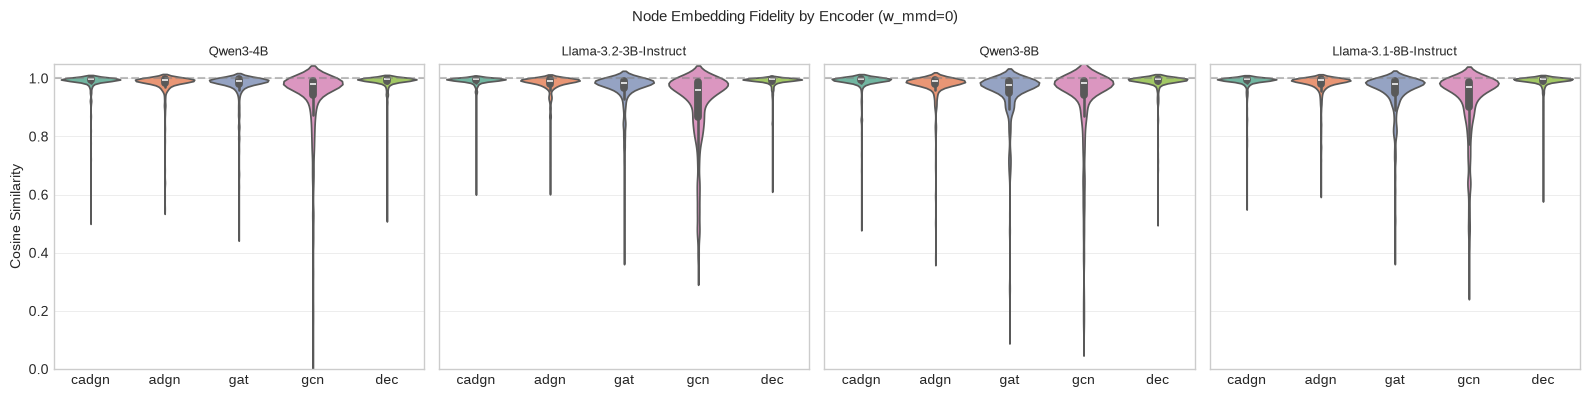

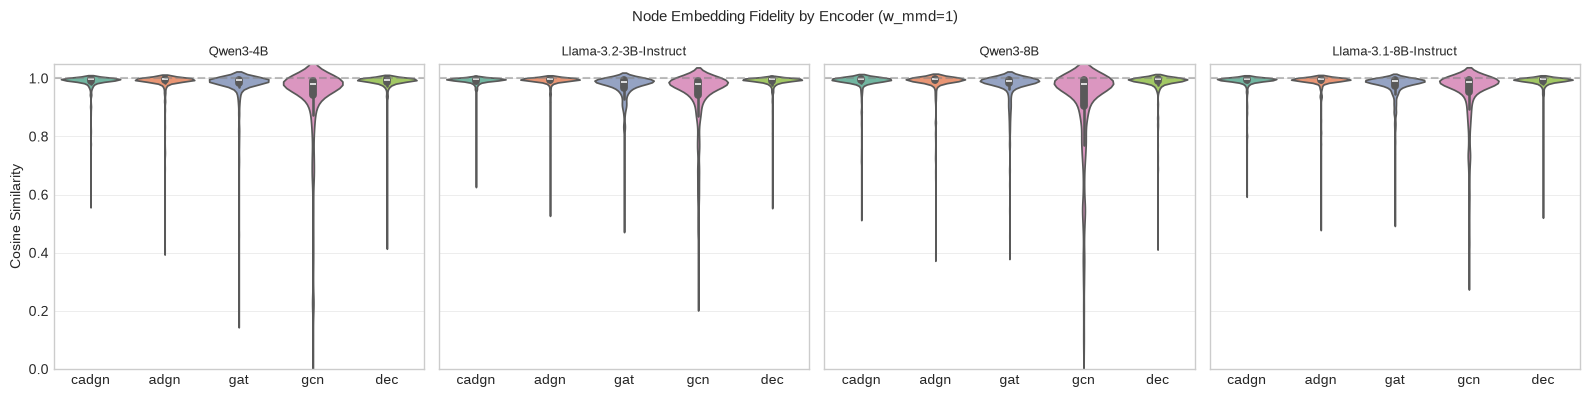

In [11]:
# Violin plot to show distribution of semantic drift (1-cos sim)
plt.style.use("seaborn-v0_8-whitegrid")
cosine_exploded = (
    cosine_df
    .explode("cosine_sim_per_node")
    .rename({"cosine_sim_per_node": "cosine_sim"})
)

# Convert to pandas for seaborn plotting
for mi, mmd_val in enumerate([0,1]):
    df_plot = cosine_exploded.filter(
        pl.col("mmd_val") == mmd_val
    ).to_pandas()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for ax, llm in zip(axes, do_models):
        subset = df_plot[df_plot["llm"] == llm]
        sns.violinplot(
            data=subset,
            x="ablation",
            y="cosine_sim",
            ax=ax,
            order=["cadgn", "adgn", "gat", "gcn", "dec"],
            palette="Set2",
        )
        ax.set_title(llm.split("/")[-1], fontsize=9)
        ax.set_xlabel("")
        ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
        ax.set_ylim(0, 1.05)

    axes[0].set_ylabel("Cosine Similarity")
    fig.suptitle(f"Node Embedding Fidelity by Encoder (w_mmd={mmd_val})", fontsize=11)
    plt.tight_layout()
    fig.savefig(stage1_output_graph_path / f"node_embedding_fidelity_mmd-{mmd_val}.png")



In [12]:
# Join together
derived_df = auprc_df.join(
    cosine_df,
    on=["sample_id", "ablation", "mmd_val", "llm"],
    how="inner",
)

In [13]:
print("=== Loss Summary ===")
print(summary)

print("\n=== Derived Metrics (first 20 rows)")
print(derived_df.head(20))

# Per-Graph aggregation
per_graph = (
    derived_df
    .group_by(["graph_id", "ablation", "mmd_val", "llm"])
    .agg([
        pl.col("auprc").mean().alias("auprc_mean"),
        pl.col("cosine_sim_mean").mean().alias("cosine_sim_mean"),
        pl.col("density").first(),
        pl.col("num_nodes").first(),
        pl.col("num_edges").first(),
    ])
    .sort(["graph_id", "ablation"])
)

print("\n=== Per-Graph Summary===")
print(per_graph)

# Save results
summary.write_csv(stage1_output_graph_path / "stage1_loss_summary.csv")
derived_df.write_parquet(stage1_output_graph_path / "stage1_derived_metrics.parquet")
per_graph.write_csv(stage1_output_graph_path / "stage1_per_graph.csv")

=== Loss Summary ===
shape: (40, 11)
┌──────────┬─────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ablation ┆ mmd_val ┆ llm        ┆ L_nodes_me ┆ … ┆ L_norm_me ┆ L_total_m ┆ L_mmd_mea ┆ n_samples │
│ ---      ┆ ---     ┆ ---        ┆ an         ┆   ┆ an        ┆ ean       ┆ n         ┆ ---       │
│ str      ┆ i64     ┆ str        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ u32       │
│          ┆         ┆            ┆ f64        ┆   ┆ f64       ┆ f64       ┆ f64       ┆           │
╞══════════╪═════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ adgn     ┆ 0       ┆ Qwen/Qwen3 ┆ 0.020344   ┆ … ┆ 0.025431  ┆ 0.115024  ┆ 0.153391  ┆ 1707      │
│          ┆         ┆ -4B        ┆            ┆   ┆           ┆           ┆           ┆           │
│ adgn     ┆ 0       ┆ Qwen/Qwen3 ┆ 0.029196   ┆ … ┆ 0.024667  ┆ 0.115024  ┆ 0.153391  ┆ 1707      │
│          ┆         ┆ -8B        ┆            ┆   ┆  

In [14]:
# Present in simplified table (derived_df)
per_mmd = (
    derived_df
    .group_by(["ablation", "llm", "mmd_val"])
    .agg([
        pl.col("auprc").mean().alias("auprc_mean"),
        pl.col("cosine_sim_mean").mean().alias("cosine_sim_mean"),
        pl.col("cosine_sim_min").mean().alias("cosine_sim_min"),
    ])
    .sort(["llm", "ablation", "mmd_val"])
)
# Pivot mmd_val into columns
metrics = ["auprc_mean", "cosine_sim_mean", "cosine_sim_min"]

summary_wide = per_mmd.pivot(
    on="mmd_val",
    index=["ablation", "llm"],
    values=metrics,
)

# Add difference column (to show which is better)
for metric in metrics:
    summary_wide = summary_wide.with_columns(
        (pl.col(f"{metric}_1") - pl.col(f"{metric}_0")).alias(f"{metric}_delta")
    )
summary_wide = summary_wide.sort(["llm", "ablation"])
summary_wide.write_csv(stage1_output_graph_path / "stage1_summary_wide.csv")

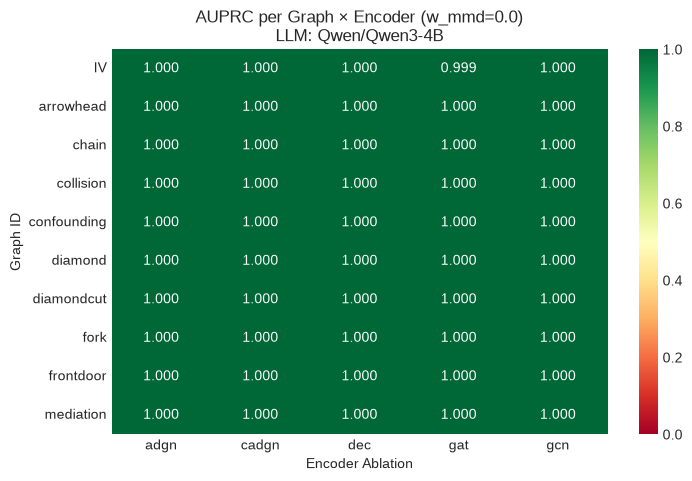

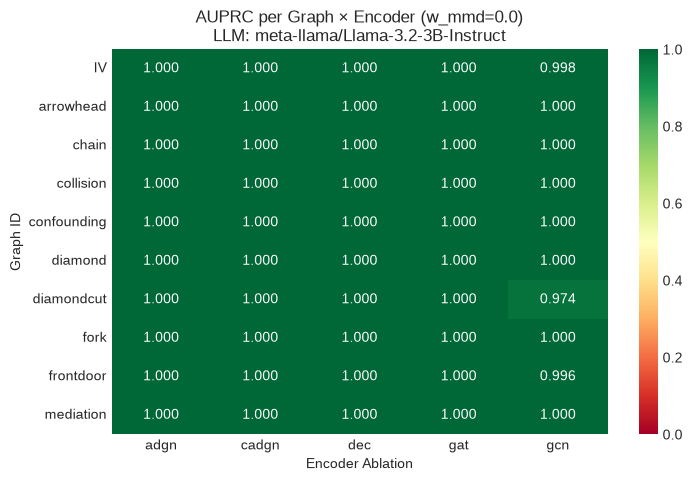

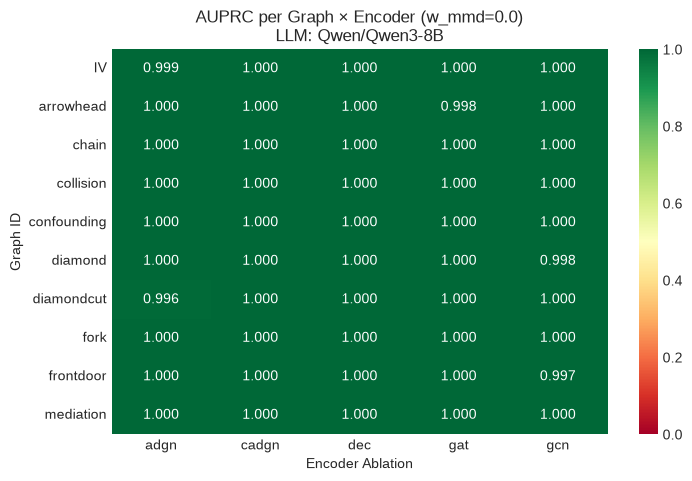

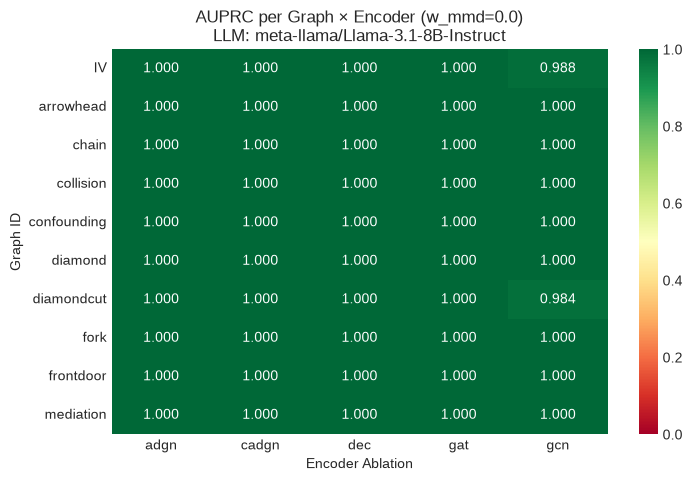

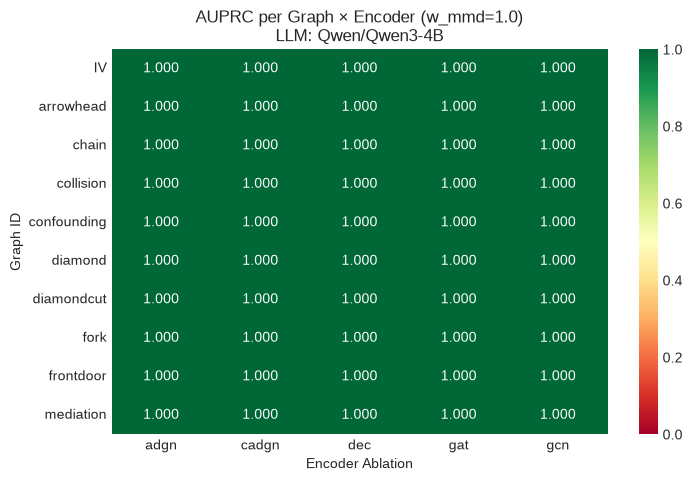

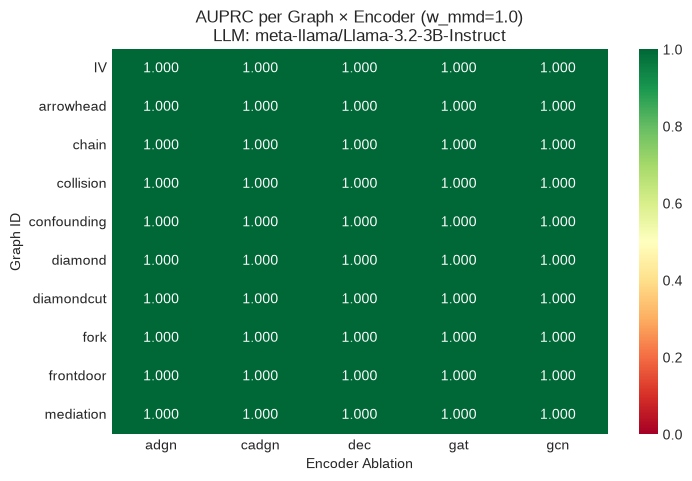

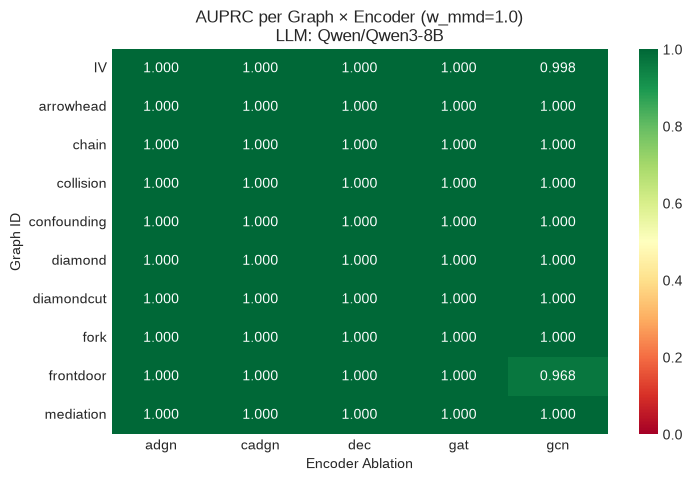

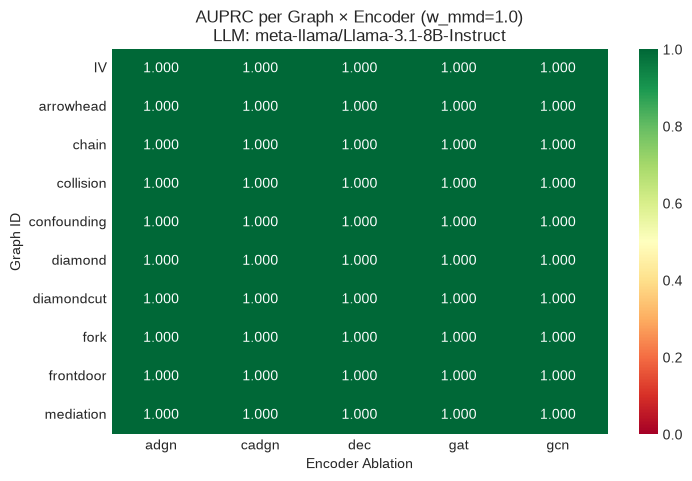

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sp_edges = stage1_output_graph_path / "edges"
sp_edges.mkdir(parents=True, exist_ok=True)

for mi, mmd_val in enumerate(mmd_vals):
    for mj, mdl in enumerate(do_models):
        safename: str = mdl.replace("/", "__")
        pivot = (
            per_graph
            .filter(pl.col("mmd_val") == mmd_val)   # pick one mmd_val for clarity
            .filter(pl.col("llm") == mdl)  # or average across LLMs
            .pivot(values="auprc_mean", index="graph_id", on="ablation")
            .to_pandas()
            .set_index("graph_id")
        )

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
                    vmin=0.0, vmax=1.0)
        ax.set_title(f"AUPRC per Graph × Encoder (w_mmd={mmd_val})\nLLM: {mdl}")
        ax.set_xlabel("Encoder Ablation")
        ax.set_ylabel("Graph ID")

        fig.savefig(sp_edges / f"s1_{mmd_val}_{mj}__{safename}_per_graph_heatmap.png")

Fitting UMAP on 2064 vectors (both mmd_vals combined)...


/home/jerry/venvs/CausalADGN_venv/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete. embedding_2d shape: (2064, 2)
Plotting 50 samples
Outlier threshold (q0.9): 16.2235


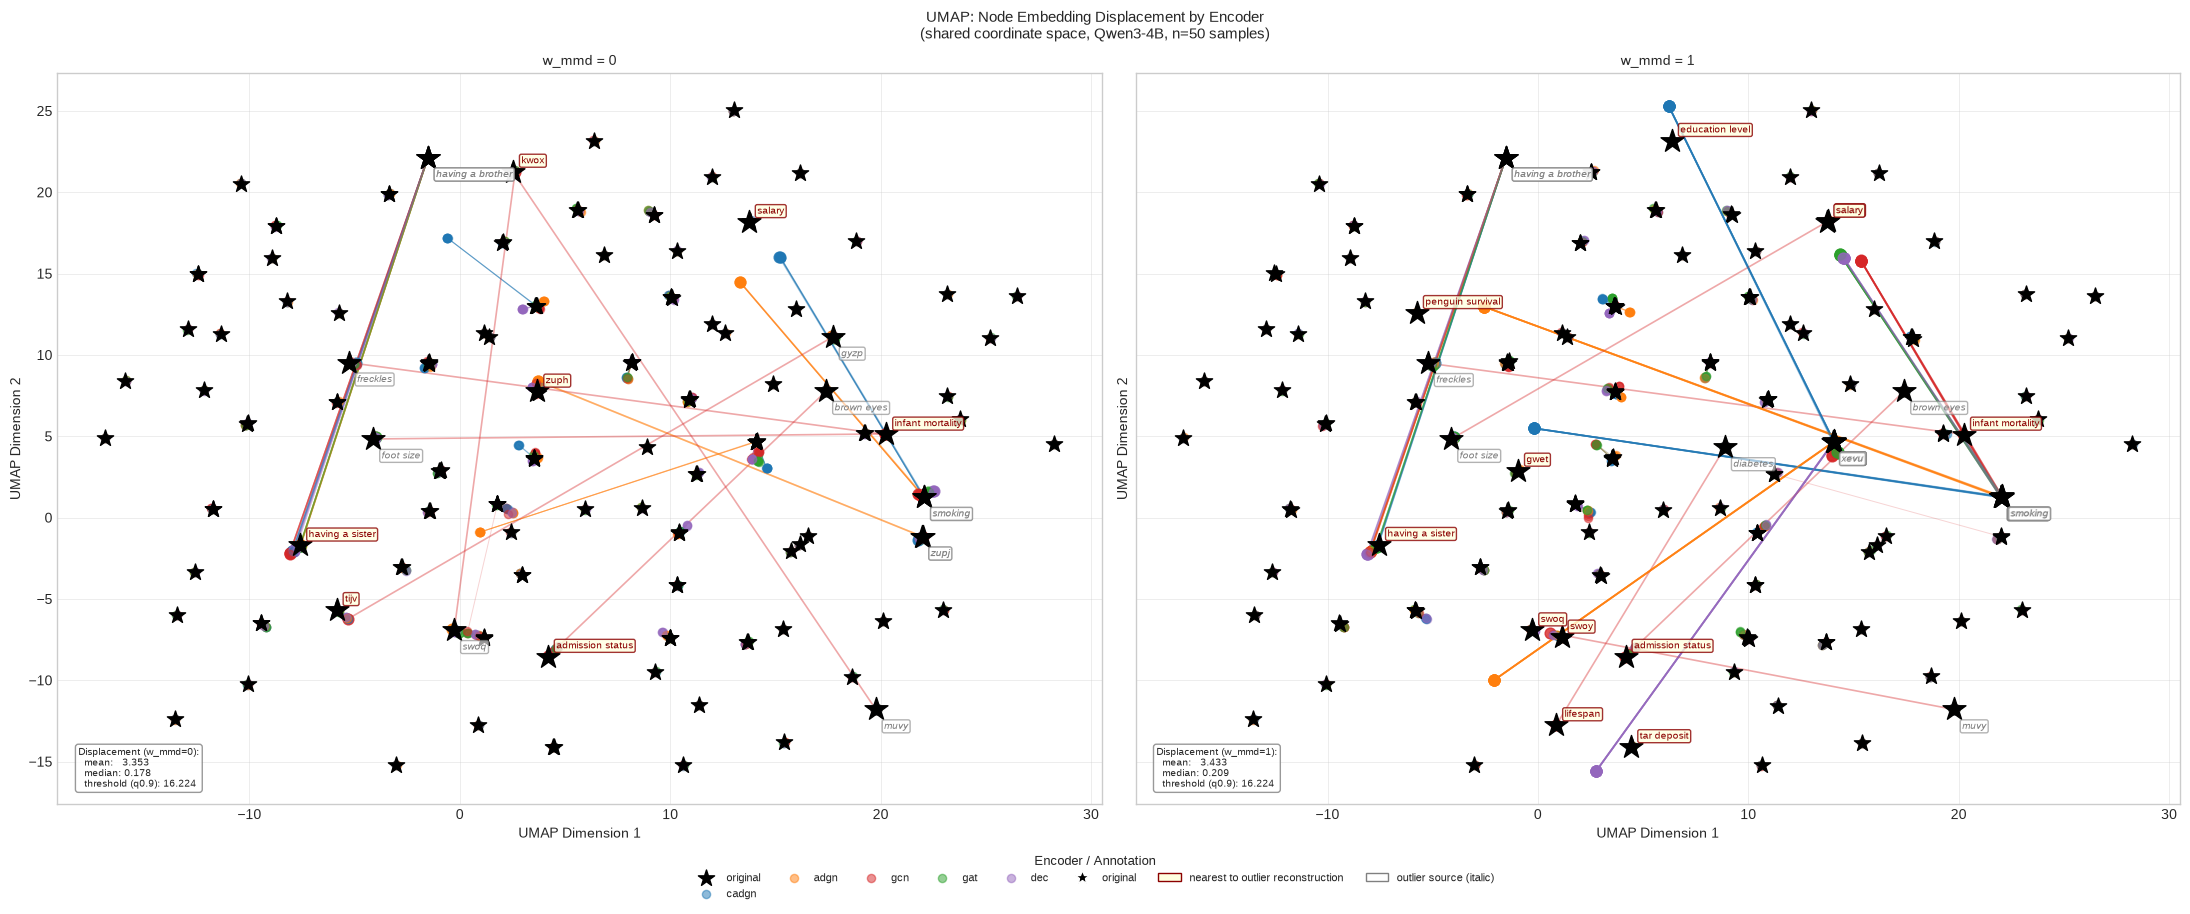

In [16]:
# UMAP generate & save
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

USE_SAMPLES = 50
OUTLIER_THRESHOLD_QUANTILE = 0.9  # label top 10% most displaced stars

colours = {
    "original": "black",
    "cadgn":    "#1f77b4",
    "adgn":     "#ff7f0e",
    "gat":      "#2ca02c",
    "gcn":      "#d62728",
    "dec":      "#9467bd",
}

# Step 1: Assemble all vectors for UMAP fitting
all_vecs    = []
all_labels  = []
all_is_orig = []
all_mmd_tag = []   # track which mmd_val each vector belongs to

for mmd_val in [0, 1]:
    for sample_id, orig_vecs in umap_originals.items():
        # Originals: identical for both mmd_vals but included in each
        # so position lookups work per-mmd_val subplot
        for node_vec in orig_vecs:
            all_vecs.append(node_vec)
            all_labels.append("original")
            all_mmd_tag.append(mmd_val)

        for abl in model_ablations:
            recon = umap_reconstructed[sample_id][mmd_val].get(abl)
            if recon is None:
                continue
            for node_vec in recon:
                all_vecs.append(node_vec)
                all_labels.append(abl)
                all_mmd_tag.append(mmd_val)

all_vecs_np = np.stack(all_vecs)
print(f"Fitting UMAP on {all_vecs_np.shape[0]} vectors "
      f"(both mmd_vals combined)...")

# Step 2: Fit UMAP
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    init="random",
)

jitter = np.random.default_rng(42).normal(0, 1e-4, all_vecs_np.shape)
embedding_2d = reducer.fit_transform(all_vecs_np + jitter)
# shape: (n_total_vectors, 2)

print(f"UMAP complete. embedding_2d shape: {embedding_2d.shape}")

# Step 3: Pick USE_SAMPLES sample_ids with complete reconstructions
use_sample_ids = set()
for sample_id in umap_originals:
    if all(
        umap_reconstructed[sample_id][mmd_val].get(abl) is not None
        for abl in model_ablations
        for mmd_val in [0, 1]
    ):
        use_sample_ids.add(sample_id)
        if len(use_sample_ids) >= USE_SAMPLES:
            break


print(f"Plotting {len(use_sample_ids)} samples")

# Step 4: Build position lookups by re-walking assembly order
# Separate lookups per mmd_val
orig_pos_lookup:  dict[tuple[int, int, int], np.ndarray] = {}
recon_pos_lookup: dict[tuple[int, int, int, str], np.ndarray] = {}
# keys: (mmd_val, sample_id, node_idx) and (mmd_val, sample_id, node_idx, abl)

vec_idx = 0
for mmd_val in [0, 1]:
    for sample_id, orig_vecs in umap_originals.items():
        n_nodes = len(orig_vecs)

        for node_idx in range(n_nodes):
            if sample_id in use_sample_ids:
                orig_pos_lookup[(mmd_val, sample_id, node_idx)] = embedding_2d[vec_idx]
            vec_idx += 1

        for abl in model_ablations:
            recon = umap_reconstructed[sample_id][mmd_val].get(abl)
            if recon is None:
                continue
            for node_idx in range(n_nodes):
                if sample_id in use_sample_ids:
                    recon_pos_lookup[(mmd_val, sample_id, node_idx, abl)] = embedding_2d[vec_idx]
                vec_idx += 1


# Step 5: Compute max displacement per key: (mmd_val, sample_id, node_idx)
displacements: dict[tuple[int, int, int], float] = {}

for mmd_val in [0, 1]:
    for (mv, sample_id, node_idx), orig_pos in orig_pos_lookup.items():
        if mv != mmd_val:
            continue
        max_dist = 0.0
        for abl in model_ablations:
            recon_pos = recon_pos_lookup.get((mmd_val, sample_id, node_idx, abl))
            if recon_pos is None:
                continue
            dist = float(np.linalg.norm(orig_pos - recon_pos))
            max_dist = max(max_dist, dist)
        displacements[(mmd_val, sample_id, node_idx)] = max_dist

all_disps   = np.array(list(displacements.values()))
threshold   = float(np.quantile(all_disps, OUTLIER_THRESHOLD_QUANTILE))


print(f"Outlier threshold (q{OUTLIER_THRESHOLD_QUANTILE}): {threshold:.4f}")

# Build nearest-star labels per mmd_val
def build_stars_to_label(mmd_val: int) -> dict[tuple[int, int, int], str]:
    orig_keys = [k for k in orig_pos_lookup if k[0] == mmd_val]
    orig_pos_arr = np.stack([orig_pos_lookup[k] for k in orig_keys])

    stars: dict[tuple[int, int, int], str] = {}

    for (mv, sample_id, node_idx), orig_pos in orig_pos_lookup.items():
        if mv != mmd_val:
            continue
        if displacements.get((mmd_val, sample_id, node_idx), 0.0) < threshold:
            continue

        for abl in model_ablations:
            recon_pos = recon_pos_lookup.get((mmd_val, sample_id, node_idx, abl))
            if recon_pos is None:
                continue
            if np.linalg.norm(orig_pos - recon_pos) < threshold:
                continue

            dists = np.linalg.norm(orig_pos_arr - recon_pos, axis=1)
            own_idx = orig_keys.index((mmd_val, sample_id, node_idx))
            dists[own_idx] = np.inf

            nearest_key = orig_keys[int(np.argmin(dists))]
            nearest_sample = sample_lookup.get(nearest_key[1])
            nearest_label = (
                nearest_sample.node_names[nearest_key[2]]
                if nearest_sample is not None
                   and nearest_key[2] < len(nearest_sample.node_names)
                else f"{nearest_key[1]}[{nearest_key[2]}]"
            )
            if nearest_key not in stars:
                stars[nearest_key] = nearest_label

    return stars


def plot_mmd_subplot(ax, mmd_val: int, stars_to_label: dict):
    already_labelled = set()

    for sample_id in umap_originals:
        if sample_id not in use_sample_ids:
            continue

        sample  = sample_lookup.get(sample_id)
        n_nodes = len(umap_originals[sample_id])

        for node_idx in range(n_nodes):
            orig_pos = orig_pos_lookup.get((mmd_val, sample_id, node_idx))
            if orig_pos is None:
                continue

            is_outlier           = displacements.get((mmd_val, sample_id, node_idx), 0.0) >= threshold
            is_nearest_to_outlier = (mmd_val, sample_id, node_idx) in stars_to_label

            ax.scatter(
                orig_pos[0], orig_pos[1],
                c="black", marker="*",
                s=300 if (is_outlier or is_nearest_to_outlier) else 150,
                zorder=5,
                label="original" if "original" not in already_labelled else None,
            )
            already_labelled.add("original")

            if is_nearest_to_outlier:
                ax.annotate(
                    stars_to_label[(mmd_val, sample_id, node_idx)],
                    xy=orig_pos, xytext=(6, 6),
                    textcoords="offset points", fontsize=7,
                    color="darkred", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="lightyellow", ec="darkred", alpha=0.8),
                )

            if is_outlier:
                own_label = (
                    sample.node_names[node_idx]
                    if sample is not None and node_idx < len(sample.node_names)
                    else f"{sample_id}[{node_idx}]"
                )
                ax.annotate(
                    own_label,
                    xy=orig_pos, xytext=(6, -14),
                    textcoords="offset points", fontsize=7,
                    color="gray", zorder=6, fontstyle="italic",
                    bbox=dict(boxstyle="round,pad=0.2",
                              fc="white", ec="gray", alpha=0.6),
                )

            for abl in model_ablations:
                recon_pos = recon_pos_lookup.get((mmd_val, sample_id, node_idx, abl))
                if recon_pos is None:
                    continue

                ax.plot(
                    [orig_pos[0], recon_pos[0]],
                    [orig_pos[1], recon_pos[1]],
                    color=colours[abl],
                    alpha=0.4 if is_outlier else 0.2,
                    linewidth=1.2 if is_outlier else 0.7,
                    zorder=2,
                )
                ax.scatter(
                    recon_pos[0], recon_pos[1],
                    c=colours[abl], marker="o",
                    s=60 if is_outlier else 35,
                    alpha=0.8 if is_outlier else 0.5,
                    zorder=3,
                    label=abl if abl not in already_labelled else None,
                )
                already_labelled.add(abl)

    mean_disp   = float(np.mean([v for (mv, _, __), v in displacements.items() if mv == mmd_val]))
    median_disp = float(np.median([v for (mv, _, __), v in displacements.items() if mv == mmd_val]))
    ax.text(
        0.02, 0.02,
        f"Displacement (w_mmd={mmd_val}):\n"
        f"  mean:   {mean_disp:.3f}\n"
        f"  median: {median_disp:.3f}\n"
        f"  threshold (q{OUTLIER_THRESHOLD_QUANTILE}): {threshold:.3f}",
        transform=ax.transAxes, fontsize=7,
        verticalalignment="bottom",
        bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
    )
    ax.set_title(f"w_mmd = {mmd_val}", fontsize=10)
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")


## Assemble Figure
fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharex=True, sharey=True)

for mmd_val, ax in zip([0, 1], axes):
    stars = build_stars_to_label(mmd_val)
    plot_mmd_subplot(ax, mmd_val, stars)

# Shared legend on figure
handles, labels_leg = axes[0].get_legend_handles_labels()
extra = [
    Line2D([0], [0], marker="*", color="w", markerfacecolor="black",
           markersize=10, label="original"),
    Patch(facecolor="lightyellow", edgecolor="darkred",
          label="nearest to outlier reconstruction"),
    Patch(facecolor="white", edgecolor="gray",
          label="outlier source (italic)"),
]
fig.legend(
    handles=handles + extra,
    title="Encoder / Annotation",
    fontsize=8, title_fontsize=9,
    loc="lower center",
    ncol=len(model_ablations) + 3,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(
    f"UMAP: Node Embedding Displacement by Encoder\n"
    f"(shared coordinate space, {UMAP_LLM_STR.split('/')[-1]}, "
    f"n={len(use_sample_ids)} samples)",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    stage1_output_graph_path /
    f"umap_{UMAP_LLM_STR.split('/')[-1]}_sidebyside.png",
    dpi=300, bbox_inches="tight"
)
plt.show()